# Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, recall_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap

# Import Final Log Data and Preprocess Data

In [13]:
## Import the dataset
# from google.colab import files
# import io

# Upload file manually
# uploaded = files.upload()

# Read it using the filename
# filename = list(uploaded.keys())[0]  # automatically gets the uploaded filename
# df = pd.read_excel(io.BytesIO(uploaded[filename]))

df = catalog.load("preprocessed_log_dataset")

# Now you can inspect
df.info()
df.describe(include='all')

[05/08/25 13:53:43] INFO     Loading data from preprocessed_log_dataset (ParquetDataset)...     ]8;id=547782;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=303996;file:///Users/carlos/anaconda3/envs/env-01/lib/python3.9/site-packages/kedro/io/data_catalog.py#401\401]8;;\

<class 'pandas.core.frame.DataFrame'>
Index: 5683 entries, 0 to 5959
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BAD                  5683 non-null   int64  
 1   LOAN                 5683 non-null   float64
 2   MORTDUE              5683 non-null   float64
 3   VALUE                5683 non-null   float64
 4   YOJ                  5683 non-null   float64
 5   DEROG                5683 non-null   float64
 6   DELINQ               5683 non-null   float64
 7   CLAGE                5683 non-null   float64
 8   NINQ                 5683 non-null   float64
 9   CLNO                 5683 non-null   float64
 10  DEBTINC              5683 non-null   float64
 11  VALUE_missing        5683 non-null   int64  
 12  DEROG_missing        5683 non-null   int64  
 13  DELINQ_missing       5683 non-null   int64  
 14  NINQ_missing         5683 non-null   int64  
 15  DEBTINC_missing      5683 non-null   int64 

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,REASON_DebtCon,REASON_HomeImp,REASON_Not Provided,JOB_Mgr,JOB_Not Provided,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
count,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,...,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000,5683.000000
mean,0.198663,9.686999,11.033487,11.413211,1.955734,0.082826,0.142736,179.196183,0.544039,21.357734,...,0.672708,0.298434,0.028858,0.132149,0.025515,0.165406,0.404188,0.220306,0.019180,0.033257
std,0.399029,0.573341,0.623128,0.497947,0.895173,0.225387,0.288365,82.899837,0.610691,10.050451,...,0.469266,0.457611,0.167422,0.338682,0.157696,0.371579,0.490777,0.414490,0.137169,0.179323
min,0.000000,7.003974,7.632401,8.987322,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.332646,10.775252,11.111918,1.386294,0.000000,0.000000,116.204790,0.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,9.711176,11.082158,11.405847,2.079442,0.000000,0.000000,173.500000,0.693147,20.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,10.064798,11.401497,11.691933,2.639057,0.000000,0.000000,229.515518,1.098612,26.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,1.000000,11.406464,12.898097,13.659921,3.737670,1.080418,1.080418,649.747104,2.397895,55.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df_final_log = df.copy()

# Identify numerical columns
numerical_columns = df_final_log.select_dtypes(include=['number']).columns.tolist()

# Identify binary columns (only contain 0 and 1)
binary_columns = [col for col in numerical_columns if set(df_final_log[col].unique()).issubset({0, 1})]

# Identify non-binary numerical columns
non_binary_numerical_columns = [col for col in numerical_columns if col not in binary_columns and col != 'BAD']

# Standard scale only the non-binary numerical columns
scaler = StandardScaler()
df_final_log[non_binary_numerical_columns] = scaler.fit_transform(df_final_log[non_binary_numerical_columns])

# Drop target column and separate X, y
X = df_final_log.drop(columns='BAD')
y = df_final_log['BAD']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train_scaled_df = pd.DataFrame(X_train, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test, columns=X.columns)

# Forward Feature Selection using Logistic Regression
logreg = LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=10000)

sfs = SequentialFeatureSelector(
    logreg,
    direction='forward',
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train_scaled_df, y_train)

# Get selected feature names
selected_features = X_train_scaled_df.columns[sfs.get_support()]
print("Selected features for all models:")
print(list(selected_features))

# Keep only selected features in scaled datasets
X_train = X_train_scaled_df[selected_features]
X_test = X_test_scaled_df[selected_features]


Selected features for all models:
['LOAN', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'VALUE_missing', 'DEROG_missing', 'DEBTINC_missing', 'JOB_Office', 'JOB_Sales']


# Use the best model

In [15]:
""" Stacked Ensemble is our best Model """

# Define all base learners
base_learners = [
    ('lr', LogisticRegression(C=0.01, class_weight='balanced', penalty='l2', solver='liblinear', max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(class_weight='balanced', max_depth=10, max_features='sqrt', min_samples_leaf=5, min_samples_split=2, n_estimators=1500, random_state=42)),
    ('dt', DecisionTreeClassifier(class_weight='balanced', criterion='gini', max_depth=3, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, random_state=42)),
    ('mlp', MLPClassifier(activation='relu', alpha=0.0001, hidden_layer_sizes=(128, 64, 32), learning_rate='constant', solver='adam', random_state=42)),
    ('xgb', XGBClassifier(learning_rate=0.1, max_depth=4, min_child_weight=5, n_estimators=100, scale_pos_weight=10, subsample=1.0, random_state=42)),
    ('catboost', CatBoostClassifier(auto_class_weights='Balanced', bootstrap_type='Bayesian', depth=4, iterations=300, l2_leaf_reg=5, learning_rate=0.1, random_state=42, verbose=0))
]

# Meta-learner
meta_learner = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Stacking Classifier setup
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# Train the model
stack_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(C=0.01,
                                                   class_weight='balanced',
                                                   max_iter=1000,
                                                   random_state=42,
                                                   solver='liblinear')),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       min_samples_leaf=5,
                                                       n_estimators=1500,
                                                       random_state=42)),
                               ('dt',
                                DecisionTreeClassifier(class_weight='balanced',
                                                       max_depth=3,
                                                       max_features='sqrt',
                                                       r...
                                              max_leaves=None,
                                              min_child_weight=5, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...)),
                               ('catboost',
                                <catboost.core.CatBoostClassifier object at 0x19f3ba4f0>)],
                   final_estimator=LogisticRegression(class_weight='balanced',
                                                      max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1, passthrough=True)

In [16]:
# Predict
y_train_pred = stack_model.predict(X_train)
y_test_pred = stack_model.predict(X_test)

y_train_proba = stack_model.predict_proba(X_train)[:, 1]
y_test_proba = stack_model.predict_proba(X_test)[:, 1]

# ROC AUC
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

# Use model probabilities and actual labels
y_probs = y_test_proba
y_true = y_test

# Sensitivity Analysis

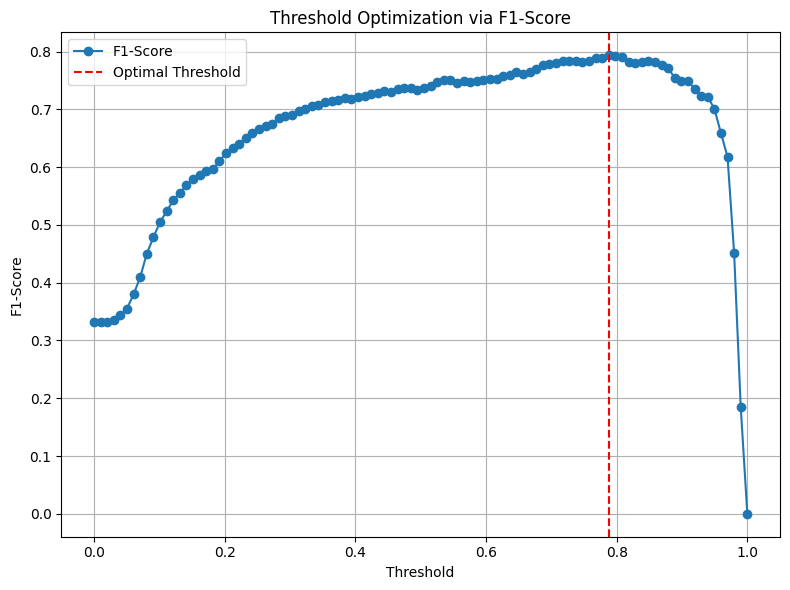

Optimal Threshold: 0.79
Confusion Matrix (Optimal Threshold):
 [[868  43]
 [ 49 177]]
Confusion Matrix (Original Threshold):
 [[806 105]
 [ 34 192]]

Classification Report (Optimal Threshold):
               precision    recall  f1-score   support

           0       0.95      0.95      0.95       911
           1       0.80      0.78      0.79       226

    accuracy                           0.92      1137
   macro avg       0.88      0.87      0.87      1137
weighted avg       0.92      0.92      0.92      1137


Classification Report (Original Threshold):
               precision    recall  f1-score   support

           0       0.96      0.88      0.92       911
           1       0.65      0.85      0.73       226

    accuracy                           0.88      1137
   macro avg       0.80      0.87      0.83      1137
weighted avg       0.90      0.88      0.88      1137



In [17]:
# Define thresholds and store F1 scores
thresholds = np.linspace(0, 1, 100)
f1_scores = []

for threshold in thresholds:
    y_pred_thresholded = (y_probs >= threshold).astype(int)
    f1 = f1_score(y_true, y_pred_thresholded)
    f1_scores.append(f1)

# Plot F1 vs Threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, marker='o', label='F1-Score')
plt.axvline(x=thresholds[np.argmax(f1_scores)], color='red', linestyle='--', label='Optimal Threshold')
plt.title('Threshold Optimization via F1-Score')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Get the optimal threshold
optimal_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal Threshold: {optimal_threshold:.2f}")

y_test_pred_opt = (y_test_proba >= optimal_threshold).astype(int)

print("Confusion Matrix (Optimal Threshold):\n", confusion_matrix(y_test, y_test_pred_opt))
print("Confusion Matrix (Original Threshold):\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Optimal Threshold):\n", classification_report(y_test, y_test_pred_opt))
print("\nClassification Report (Original Threshold):\n", classification_report(y_test, y_test_pred))

In [18]:
# Define thresholds to evaluate
thresholds = {
    "Balanced (0.50)": 0.50,
    "Risk-Averse (0.80)": 0.80,
    "Risk-Taking (0.90)": 0.90
}

# Loop through thresholds
for label, threshold in thresholds.items():
    print(f"\n===== Evaluation at Threshold: {label} =====")

    # Predict labels based on threshold
    y_test_pred_thresh = (y_test_proba >= threshold).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_test_pred_thresh)
    print("Confusion Matrix:")
    print(cm)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred_thresh))


===== Evaluation at Threshold: Balanced (0.50) =====
Confusion Matrix:
[[806 105]
 [ 34 192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       911
           1       0.65      0.85      0.73       226

    accuracy                           0.88      1137
   macro avg       0.80      0.87      0.83      1137
weighted avg       0.90      0.88      0.88      1137


===== Evaluation at Threshold: Risk-Averse (0.80) =====
Confusion Matrix:
[[869  42]
 [ 51 175]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       911
           1       0.81      0.77      0.79       226

    accuracy                           0.92      1137
   macro avg       0.88      0.86      0.87      1137
weighted avg       0.92      0.92      0.92      1137


===== Evaluation at Threshold: Risk-Taking (0.90) =====
Confusion Matrix:
[[883  28]
 [ 74 152]]

Classi

# Feature Importance

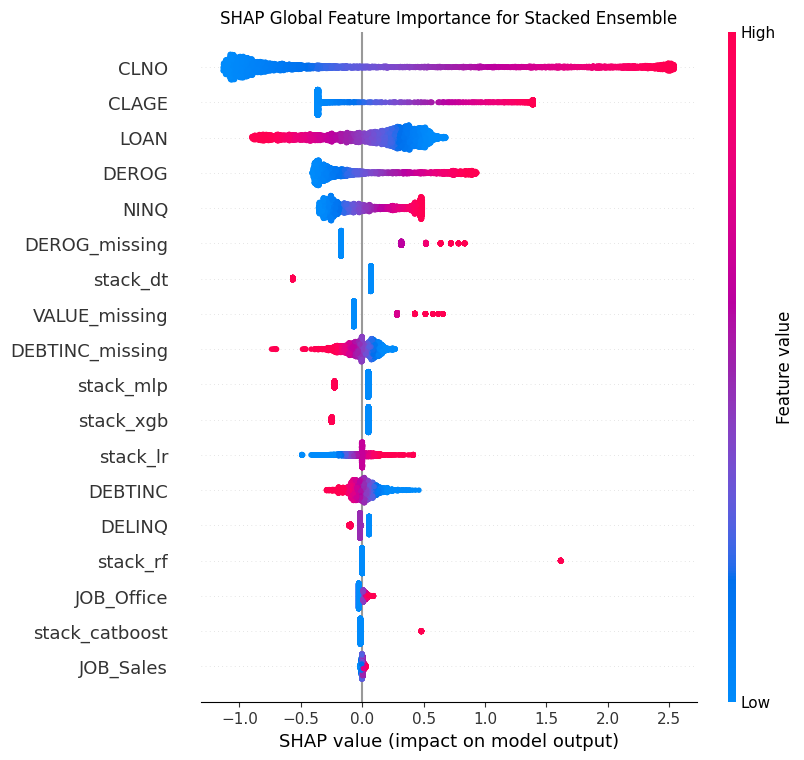

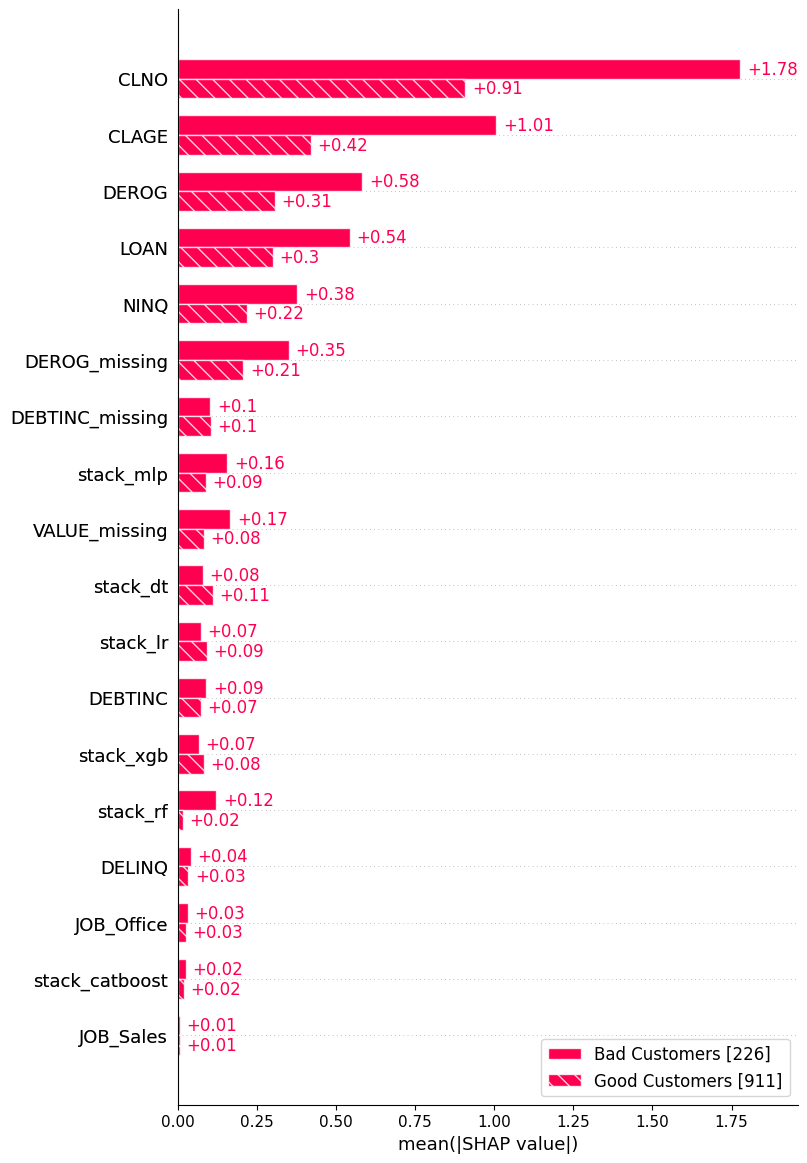

In [19]:
# Get the transformed feature matrix
X_stack_input = stack_model.transform(X_train)

# Build proper feature names
# Get passthrough features (original features)
original_features = X_train.columns.tolist()

# Get names of base learners
base_model_names = [name for name, _ in base_learners]

# Combine names: original features + base model outputs
feature_names = original_features + [f"stack_{name}" for name in base_model_names]

# Convert to DataFrame with correct column names
X_stack_df = pd.DataFrame(X_stack_input, columns=feature_names)

# SHAP explainer using the final estimator
explainer = shap.Explainer(stack_model.final_estimator_, X_stack_df)
shap_values = explainer(X_stack_df)

# Beeswarm plot with correct labels
plt.title("SHAP Global Feature Importance for Stacked Ensemble")
shap.plots.beeswarm(shap_values, max_display=25)

# 1. Create labels based on actual target (or predicted class, as you wish)
bad = ["Bad Customers" if y_test.iloc[i] == 1 else "Good Customers" for i in range(len(y_test))]

# 2. Match SHAP values to X_test used for SHAP
X_stack_test_input = stack_model.transform(X_test)
X_stack_test_df = pd.DataFrame(X_stack_test_input, columns=feature_names)

# 3. Generate SHAP values for test set
explainer = shap.Explainer(stack_model.final_estimator_, X_stack_test_df)
shap_values_test = explainer(X_stack_test_df)

# 4. Cohort-based comparison
shap.plots.bar(shap_values_test.cohorts(bad).abs.mean(0), max_display=25)